In [14]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\ashok\\anaconda3\\Lib\\site-packages\\tensorflow\\python\\_pywrap_tensorflow_common.dll'
Consider using the `--user` option or check the permissions.



In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meetnagadia/human-action-recognition-har-dataset")

print("Path to dataset files:", path)

100%|██████████| 297M/297M [00:34<00:00, 8.93MB/s] 

Extracting files...


Path to dataset files: C:\Users\ashok\.cache\kagglehub\datasets\meetnagadia\human-action-recognition-har-dataset\versions\1


# Import libraries

In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from PIL import Image


# Load the HAR Dataset

In [10]:
import os
import pandas as pd
#C:\Users\ashok\.cache\kagglehub\datasets\meetnagadia\human-action-recognition-har-dataset\versions\1\Human Action Recognition


dataset_path = r"C:\Users\ashok\.cache\kagglehub\datasets\meetnagadia\human-action-recognition-har-dataset\versions\1\Human Action Recognition"

train_csv = os.path.join(dataset_path, "Training_set.csv")
test_csv = os.path.join(dataset_path, "Testing_set.csv")

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

print(train_df.head())
print(test_df.head())



      filename         label
0  Image_1.jpg       sitting
1  Image_2.jpg  using_laptop
2  Image_3.jpg       hugging
3  Image_4.jpg      sleeping
4  Image_5.jpg  using_laptop
      filename
0  Image_1.jpg
1  Image_2.jpg
2  Image_3.jpg
3  Image_4.jpg
4  Image_5.jpg


# Load images from the same folder

In [19]:
print(train_df.columns)
print(train_df.head())


Index(['filename', 'label'], dtype='object')
      filename         label
0  Image_1.jpg       sitting
1  Image_2.jpg  using_laptop
2  Image_3.jpg       hugging
3  Image_4.jpg      sleeping
4  Image_5.jpg  using_laptop


In [50]:
import os
import numpy as np
from PIL import Image


csv_path = os.path.join(dataset_path, "Training_set.csv")
print("CSV exists:", os.path.exists(csv_path))
print("CSV path:", csv_path)




base = r"C:\Users\ashok\.cache\kagglehub\datasets\meetnagadia\human-action-recognition-har-dataset\versions\1"

# Find the folder that contains the CSVs
dataset_path = None
for name in os.listdir(base):
    full = os.path.join(base, name)
    if os.path.isdir(full) and "Training_set.csv" in os.listdir(full):
        dataset_path = full
        break

print("Detected dataset path:", dataset_path)


from PIL import Image
import numpy as np


IMG_SIZE = 128

def load_image(folder, filename):
    img_path = os.path.join(folder, filename)
    img = Image.open(img_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.array(img, dtype="float32") / 255.0


train_df = pd.read_csv(os.path.join(dataset_path, "Training_set.csv"))
test_df  = pd.read_csv(os.path.join(dataset_path, "Testing_set.csv"))


train_img_folder = os.path.join(dataset_path, "train")
test_img_folder  = os.path.join(dataset_path, "test")



CSV exists: True
CSV path: C:\Users\ashok\.cache\kagglehub\datasets\meetnagadia\human-action-recognition-har-dataset\versions\1\Human Action Recognition\Training_set.csv
Detected dataset path: C:\Users\ashok\.cache\kagglehub\datasets\meetnagadia\human-action-recognition-har-dataset\versions\1\Human Action Recognition


In [43]:
train_images = []
train_labels = []

existing_files = set(os.listdir(train_img_folder))

for _, row in train_df.iterrows():
    fname = row["filename"]
    
    if fname not in existing_files:
        print("Missing:", fname)
        continue
    
    img_array = load_image(train_img_folder, fname)
    train_images.append(img_array)
    train_labels.append(row["label"])

X_train = np.array(train_images)
y_train = np.array(train_labels)

print("Train images loaded:", X_train.shape)
print("Train labels loaded:", y_train.shape)



Train images loaded: (12600, 128, 128, 3)
Train labels loaded: (12600,)


In [53]:
test_images = []

existing_test_files = set(os.listdir(test_img_folder))

for _, row in test_df.iterrows():
    fname = row["filename"]
    if fname not in existing_test_files:
        continue
    img_array = load_image(test_img_folder, fname)
    test_images.append(img_array)

X_test = np.array(test_images)
print("Test images loaded:", X_test.shape)


Test images loaded: (5400, 128, 128, 3)


In [54]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# Train/validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_enc, test_size=0.2, random_state=42, stratify=y_train_enc
)

num_classes = len(le.classes_)
input_shape = X_train.shape[1:]  # (128, 128, 3)


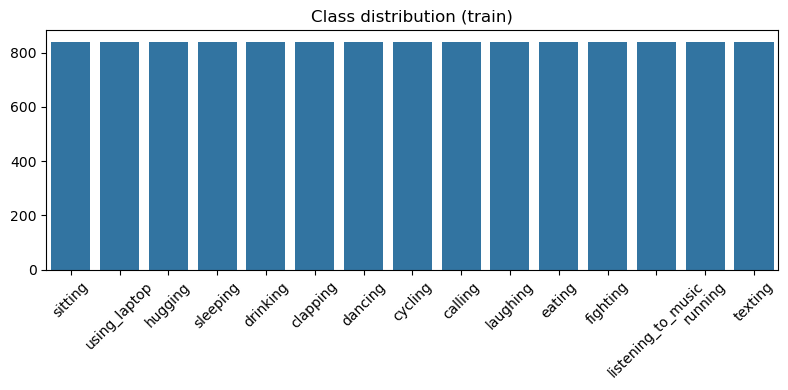

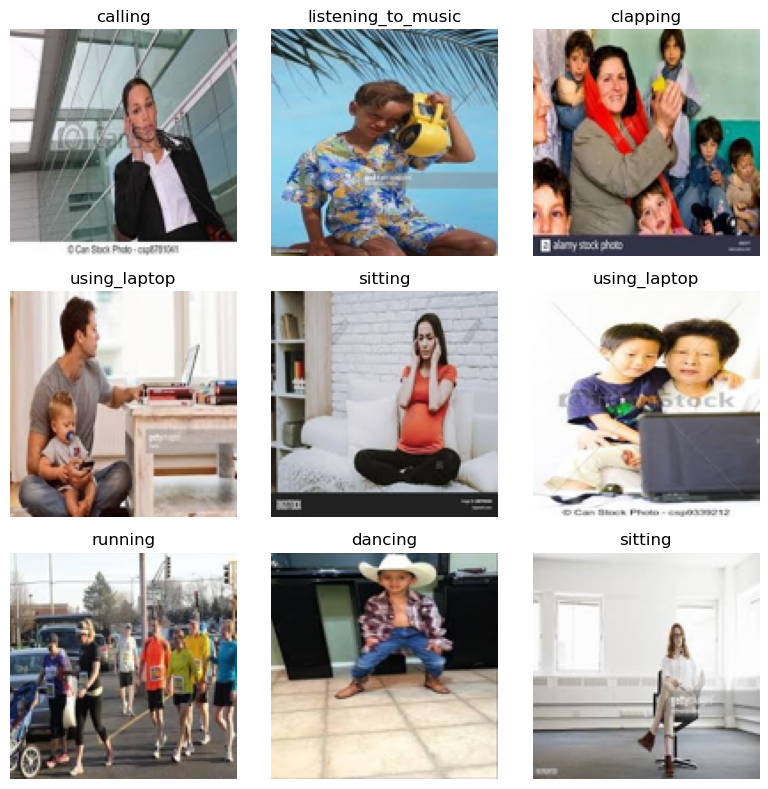

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

# Class distribution
counts = Counter(y_train)
plt.figure(figsize=(8,4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.xticks(rotation=45)
plt.title("Class distribution (train)")
plt.tight_layout()
plt.show()

# Sample images
plt.figure(figsize=(8,8))
for i in range(9):
    idx = np.random.randint(0, len(X_train))
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[idx])
    plt.title(y_train[idx])
    plt.axis("off")
plt.tight_layout()
plt.show()


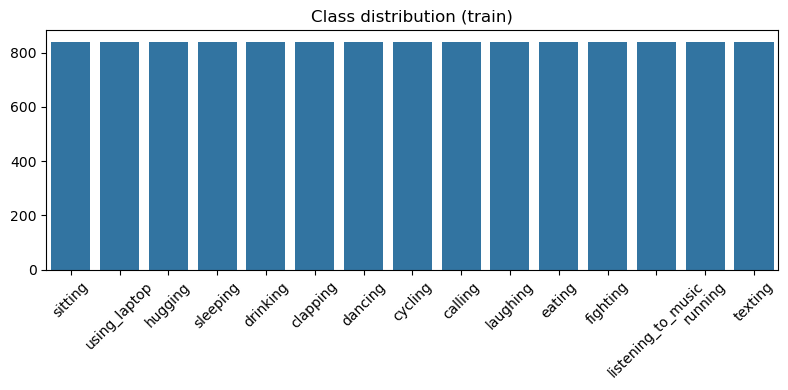

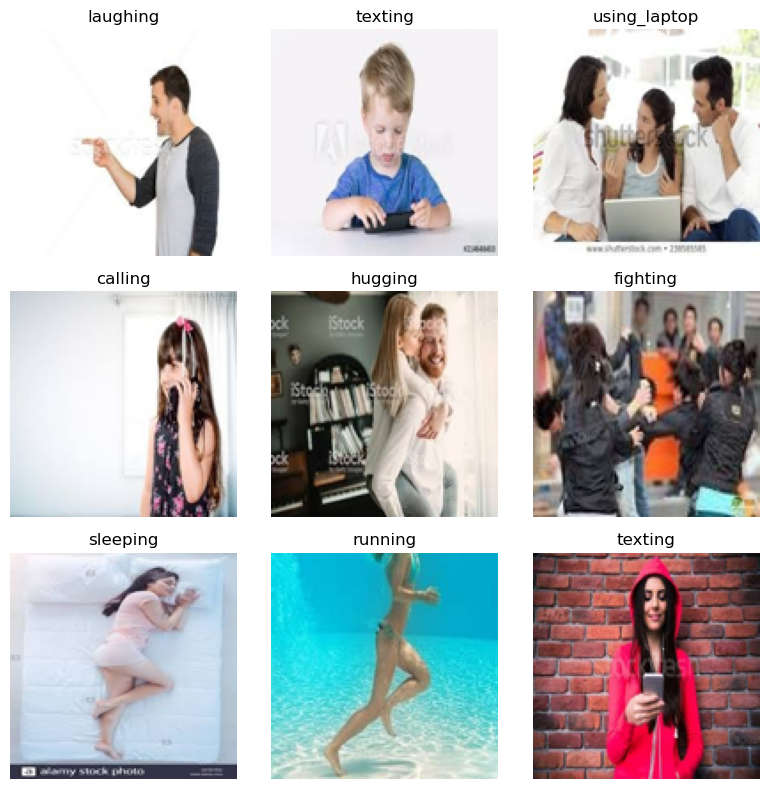

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

# Class distribution
counts = Counter(y_train)
plt.figure(figsize=(8,4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.xticks(rotation=45)
plt.title("Class distribution (train)")
plt.tight_layout()
plt.show()

# Sample images
plt.figure(figsize=(8,8))
for i in range(9):
    idx = np.random.randint(0, len(X_train))
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[idx])
    plt.title(y_train[idx])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [57]:
from tensorflow.keras import models, layers, optimizers

ann = models.Sequential([
    layers.Flatten(input_shape=input_shape),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

ann.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizers.Adam(1e-3),
    metrics=["accuracy"]
)

history_ann = ann.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)


VersionError: Detected mismatched Protobuf Gencode/Runtime major versions when loading tensorflow/core/framework/attr_value.proto: gencode 6.31.1 runtime 5.29.3. Same major version is required. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.

In [58]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 18.5 MB/s eta 0:02:33
   ---------------------------------------- 0.0/2.8 GB 21.9 MB/s eta 0:02:09
   ---------------------------------------- 0.0/2.8 GB 23.7 MB/s eta 0:01:59
   ---------------------------------------- 0.0/2.8 GB 24.7 MB/s eta 0:01:54
   ---------------------------------------- 0.0/2.8 GB 25.3 MB/s eta 0:01:51
   ---------------------------------------- 0.0/2.8 GB 25.6 MB/s eta 0:01:49
    --------------------------------------- 0.0/2.8 GB 25.6 MB/s eta 0:01:49
    --------------------------------------- 0.0/2.8 GB 25.7 MB/s eta 0:01:49
    --------------------------------------- 0.0/2.8 GB 25.7 MB/s eta 0:01:48
    --------------------------------------- 0.1/2.8 GB 25.9 MB/s eta 0:01:47
    --------------------------------------- 0.1/2.8 GB 26.1 MB/s eta 0:01:46
    ---------------------